# Results analysis

Config

In [2]:
from config import CV_DS_MAP, PUBLIC_DS_MAP

RESULT_DIR = "cv_results"
# Rename those to your own result files with better naming convention ;-)
SUBSET = "final_jepa2__142_results.csv" if RESULT_DIR == "cv_results" else "final_jepa2_142_results.csv"
METRIC = "mae"
ENFORCE_THRESHOLD = False

CLUSTER = RESULT_DIR == "cv_results"
SPLITS = ["split1", "split2", "split3"] if CLUSTER else ["split1"]

# Map Mol-JEPA dataset names -> baseline dataset names for the active mode
DS_MAP = CV_DS_MAP if CLUSTER else PUBLIC_DS_MAP

Load Mol-JEPA results

In [3]:
import os
import pandas as pd

results_files = [f for f in os.listdir(RESULT_DIR) if f.endswith(SUBSET)]

dfs = []
for f in results_files:
    fpath = os.path.join(RESULT_DIR, f)
    _df = pd.read_csv(fpath)
    _df["file_date"] = pd.to_datetime(os.path.getmtime(fpath), unit="s")
    dfs.append(_df)

df = pd.concat(dfs, ignore_index=True)
df = df[~df["dataset"].str.contains("BDB") & ~df["features"].str.contains("ecfp")]

Load baselines data

In [ ]:
import glob
import json
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# CLUSTER, SPLITS and DS_MAP are defined in the config cell above.
BASE = "baselines/clustersplits" if CLUSTER else "baselines/publicsplits"
EXCLUDED_MODELS = ["Chemprop_ECFP4", "ChempropWithECFP4"]

def _records(entry):
    """Yield (model, {y_true, y_pred, mae, mse, r2}) for every y_pred_<model> key."""
    y_true = entry.get("y_true")
    for k in entry:
        if k.startswith("y_pred_"):
            m = k[len("y_pred_"):]
            yield m, {
                "y_true": y_true,
                "y_pred": entry[k],
                "mae": entry.get(f"mae_{m}"),
                "mse": entry.get(f"mse_{m}"),
                "r2": entry.get(f"r2_{m}"),
            }
rows = {}
for fpath in glob.glob(f"{BASE}/**/baseline_*.json", recursive=True):
    data = json.load(open(fpath))
    if CLUSTER:
        # dataset comes from the (clean) folder path: <dataset>/<endpoint>
        dataset = os.path.relpath(os.path.dirname(fpath), BASE).replace(os.sep, "_")
        blocks = [(dataset, sp, e) for sp, e in data.items() if isinstance(e, dict)]
    else:
        # public files hold one or more endpoints, each is a single split
        blocks = [(ep, "split1", e) for ep, e in data.items() if isinstance(e, dict)]
    for ds, sp, entry in blocks:
        for model, rec in _records(entry):
            if model in EXCLUDED_MODELS or ds.startswith("bindingdb"):
                continue
            rec["source_file"] = fpath
            rows.setdefault((ds, model), {"dataset": ds, "model": model})[sp] = rec

baseline_df = pd.DataFrame(rows.values())

# aggregate test metrics across splits
for metric in ["mae", "mse", "r2"]:
    vals = pd.DataFrame(
        {s: [r.get(metric) if isinstance(r, dict) else np.nan for r in baseline_df[s]] for s in SPLITS}
    )
    baseline_df[f"mean_test_{metric}"] = vals.mean(axis=1)
    baseline_df[f"std_test_{metric}"] = vals.std(axis=1)

agg_cols = [f"{a}_test_{m}" for m in ["mae", "mse", "r2"] for a in ["mean", "std"]]
baseline_df = baseline_df[SPLITS + agg_cols + ["model", "dataset"]]

# Check if shapes match
for ds, g in baseline_df.groupby("dataset"):
    for s in SPLITS:
        records = [
            (r["model"], r[s])
            for _, r in g.iterrows()
            if isinstance(r[s], dict) and r[s].get("y_pred") is not None
        ]
        if not records:
            continue

        pred_lens = {model: len(rec["y_pred"]) for model, rec in records}
        major = pd.Series(pred_lens).mode().iloc[0]

        for model, rec in records:
            pred_len = pred_lens[model]
            source = rec.get("source_file", "<unknown>")
            y_true = rec.get("y_true")

            if CLUSTER and y_true is not None:
                true_len = len(y_true)
                if pred_len != true_len:
                    print(
                        f"WARNING {ds} / {s} / {model}: y_pred has {pred_len} values, "
                        f"but y_true has {true_len}; source file: {source}"
                    )
            elif pred_len != major:
                print(
                    f"WARNING {ds} / {s} / {model}: expected modal length {major}, "
                    f"got {pred_len}; source file: {source}"
                )

print("Recomputing metrics...")
mismatch_count = 0
for ds, g in baseline_df.groupby("dataset"):
    for s in SPLITS:
        for _, r in g.iterrows():
            rec = r[s]
            if not isinstance(rec, dict):
                continue
            y_true = rec.get("y_true")
            y_pred = rec.get("y_pred")
            if y_true is None or y_pred is None:
                continue
            if len(y_true) != len(y_pred):
                continue

            y_true_arr = np.asarray(y_true, dtype=float)
            y_pred_arr = np.asarray(y_pred, dtype=float)

            # Check if nan and drop
            if np.isnan(y_true_arr).any() or np.isnan(y_pred_arr).any():
                print(f"WARNING {ds} / {s} / {r['model']}: {np.isnan(y_true_arr).sum() + np.isnan(y_pred_arr).sum()} NaN values found in y_true or y_pred; dropping NaNs for metric computation.")
                nan_mask = ~np.isnan(y_true_arr) & ~np.isnan(y_pred_arr)
                y_true_arr = y_true_arr[nan_mask]
                y_pred_arr = y_pred_arr[nan_mask]

            computed_mae = mean_absolute_error(y_true_arr, y_pred_arr)
            computed_mse = mean_squared_error(y_true_arr, y_pred_arr)
            computed_r2 = r2_score(y_true_arr, y_pred_arr)

            stored_mae = rec.get("mae")
            stored_mse = rec.get("mse")
            stored_r2 = rec.get("r2")

            for metric_name, computed, stored in [
                ("mae", computed_mae, stored_mae),
                ("mse", computed_mse, stored_mse),
                ("r2", computed_r2, stored_r2),
            ]:
                if stored is None:
                    continue
                if not np.isclose(computed, stored, rtol=1e-4, atol=1e-6):
                    mismatch_count += 1
                    print(
                        f"MISMATCH {ds} / {s} / {r['model']} / {metric_name}: "
                        f"computed={computed:.6f}, stored={stored:.6f}"
                    )

if mismatch_count == 0:
    print("All metrics match between computed and stored values.")
else:
    print(f"Total mismatches: {mismatch_count}")

Ensure thresholds

As Butina Cluster splits do not ensure strict threshold splits, we additionally test hard cut-offs here - but this didn't really affect the results.

In [5]:
import re
from ast import literal_eval as _literal_eval

df_thresh = pd.read_excel("cv_results/threshold.xlsx")
df_thresh["dataset"] = df_thresh["dataset"].ffill()

def _parse_idx(val):
    """Parse an index column that may be a malformed list string (e.g. missing bracket)."""
    if not isinstance(val, str):
        return [] if pd.isna(val) else [int(val)]
    val = val.strip()
    if not val.startswith("["):
        val = "[" + val
    if not val.endswith("]"):
        val = val + "]"
    return _literal_eval(val)

def _exclude_and_score(y_true_arr, y_pred_arr, exclude_idx, context=""):
    """Mask out exclude_idx, warn on OOB, return (mae, mse, r2) or None."""
    n = len(y_true_arr)
    if exclude_idx:
        bad = [i for i in exclude_idx if i >= n]
        if bad:
            print(f"  WARNING {context}: indices {bad} >= len={n}")
        mask = np.ones(n, dtype=bool)
        mask[np.array([i for i in exclude_idx if i < n], dtype=int)] = False
        y_true_arr, y_pred_arr = y_true_arr[mask], y_pred_arr[mask]
    if len(y_true_arr) < 2:
        return None
    return (mean_absolute_error(y_true_arr, y_pred_arr),
            mean_squared_error(y_true_arr, y_pred_arr),
            r2_score(y_true_arr, y_pred_arr))

if ENFORCE_THRESHOLD:
    # Build threshold map: (dataset, split_name) -> {"sdf": [...], "json": [...]}
    thresh_map = {}
    for _, trow in df_thresh.iterrows():
        key = (trow["dataset"], f"split{int(trow['split'])}")
        entry = thresh_map.setdefault(key, {"sdf": [], "json": []})
        entry["sdf"].extend(_parse_idx(trow["sdf_file_index"]))
        entry["json"].extend(_parse_idx(trow["json_prediction_index"]))

    # Datasets that have any threshold entries
    thresh_datasets = set(ds for ds, _ in thresh_map.keys())

    # Build a lookup for y_true per (dataset, split) from any baseline record that has it
    baseline_ytrue = {}
    for idx, row in baseline_df.iterrows():
        ds = row["dataset"]
        if ds not in thresh_datasets:
            continue
        for s in SPLITS:
            rec = row[s]
            if isinstance(rec, dict) and rec.get("y_true") is not None:
                baseline_ytrue.setdefault((ds, s), np.asarray(rec["y_true"], dtype=float))

    # Re-compute baseline_df metrics (only for datasets with thresholds)
    print("Enforcing thresholds on baseline_df...")
    print(f"{'Dataset':<30} {'Model':<20} {'MAE before':>12} {'MAE after':>12} {'Δ':>8}")
    print("-" * 84)
    for idx, row in baseline_df.iterrows():
        ds = row["dataset"]
        if ds not in thresh_datasets:
            continue
        mae_before = row["mean_test_mae"]
        split_scores = []
        for s in SPLITS:
            rec = row[s]
            if not isinstance(rec, dict) or rec.get("y_pred") is None:
                continue
            y_pred_arr = np.asarray(rec["y_pred"], dtype=float)
            y_true_arr = (np.asarray(rec["y_true"], dtype=float)
                          if rec.get("y_true") is not None
                          else baseline_ytrue.get((ds, s)))
            if y_true_arr is None or len(y_true_arr) != len(y_pred_arr):
                continue
            scores = _exclude_and_score(
                y_true_arr, y_pred_arr,
                thresh_map.get((ds, s), {}).get("json", []),
                context=f"{ds}/{s}/{row['model']}")
            if scores:
                split_scores.append(scores)
        for i, m in enumerate(["mae", "mse", "r2"]):
            vals = [sc[i] for sc in split_scores]
            baseline_df.at[idx, f"mean_test_{m}"] = np.mean(vals) if vals else np.nan
            baseline_df.at[idx, f"std_test_{m}"] = np.std(vals) if vals else np.nan
        mae_after = baseline_df.at[idx, "mean_test_mae"]
        if not np.isnan(mae_before) and not np.isnan(mae_after) and abs(mae_before - mae_after) > 1e-6:
            print(f"{ds:<30} {row['model']:<20} {mae_before:>12.4f} {mae_after:>12.4f} {mae_after - mae_before:>+8.4f}")

    # Re-compute df (Mol-JEPA) metrics (only for datasets with thresholds)
    print("\nEnforcing thresholds on df (Mol-JEPA)...")
    print(f"{'Dataset':<30} {'Features':<15} {'Variant':<15} {'MAE before':>12} {'MAE after':>12} {'Δ':>8}")
    print("-" * 94)
    for idx, row in df.iterrows():
        ds = DS_MAP[row["dataset"]]
        if ds not in thresh_datasets:
            continue
        mae_before = row["mean_test_mae"]
        split_scores = []
        for s in SPLITS:
            cell = row[s]
            if (isinstance(cell, float) and pd.isna(cell)) or not cell:
                continue
            fold = _literal_eval(cell) if isinstance(cell, str) else cell
            scores = _exclude_and_score(
                np.asarray(fold["y_true_test"], dtype=float).ravel(),
                np.asarray(fold["y_pred_test"], dtype=float).ravel(),
                thresh_map.get((ds, s), {}).get("sdf", []),
                context=f"{ds}/{s}")
            if scores:
                split_scores.append(scores)
        for i, m in enumerate(["mae", "mse", "r2"]):
            vals = [sc[i] for sc in split_scores]
            df.at[idx, f"mean_test_{m}"] = np.mean(vals) if vals else np.nan
            df.at[idx, f"std_test_{m}"] = np.std(vals) if vals else np.nan
        mae_after = df.at[idx, "mean_test_mae"]
        if not np.isnan(mae_before) and not np.isnan(mae_after) and abs(mae_before - mae_after) > 1e-6:
            print(f"{ds:<30} {row.get('features',''):<15} {row.get('variant',''):<15} {mae_before:>12.4f} {mae_after:>12.4f} {mae_after - mae_before:>+8.4f}")

    print(f"\nDone. Thresholds applied to {len(thresh_map)} (dataset, split) pairs for {len(thresh_datasets)} datasets.")
    # # Save for other notebooks
df.to_csv("data/moljepa_results_thr.csv", index=False)
baseline_df.to_csv("data/baseline_results_thr.csv", index=False)

### Results table

In [6]:
lower_better = METRIC in ("mae", "mse")

MODEL_MAP = {
    "Chemprop_GNN": "Chemprop",
    "LGBM_AlvaDesc": "LGBM_desc",
    "RF_ECFP4": "RF_ECFP4",
    "Chemeleon": "Chemeleon",
    "TabICL_AlvaDesc": "TabICL_desc",
    # "TabICL_3DPF": "TabICL_3DPF",
}
cols = list(MODEL_MAP)


def build_results(metric):
    """Build the (num, disp) results tables for a given metric ('mae' or 'r2')."""
    lb = metric in ("mae", "mse")
    b_mean, b_std = f"mean_test_{metric}", f"std_test_{metric}"
    jm_mean, jm_std = f"mean_test_{metric}", f"std_test_{metric}"

    def _best(sub):
        if sub.empty or sub[jm_mean].isna().all():
            return (np.nan, np.nan)
        idx = sub[jm_mean].idxmin() if lb else sub[jm_mean].idxmax()
        return sub.loc[idx, jm_mean], sub.loc[idx, jm_std]

    records = {}
    for jd, bd in DS_MAP.items():
        bl = baseline_df[baseline_df["dataset"] == bd]
        row = {}
        for disp_name, model in MODEL_MAP.items():
            r = bl[bl["model"] == model]
            row[disp_name] = (r[b_mean].iloc[0], r[b_std].iloc[0]) if len(r) else (np.nan, np.nan)

        sub = df[df["dataset"] == jd]
        row["CLAMP"] = _best(sub[sub["features"].str.contains("clamp")])
        row["Mol-JEPA (best)"] = _best(
            sub[
                ~sub["features"].str.contains("clamp")
                & ~sub["features"].str.contains("ecfp")
            ]
        )
        row["Mol-JEPA (embeddings)"] = _best(
            sub[(sub["features"] == "embeddings") & (sub["variant"].str.contains("transformer"))]
        )
        records[jd] = row

    all_cols = cols + ["CLAMP", "Mol-JEPA (best)", "Mol-JEPA (embeddings)"]
    num = pd.DataFrame({d: {c: v[0] for c, v in r.items()} for d, r in records.items()}).T[all_cols]
    disp = pd.DataFrame(
        {d: {c: (f"{v[0]:.2f} ± {v[1]:.2f}" if pd.notna(v[0]) else "") for c, v in r.items()} for d, r in records.items()}
    ).T[all_cols]

    summary_row = pd.DataFrame(
        {c: f"{num[c].mean():.2f} ± {num[c].std():.2f}" for c in num.columns},
        index=["Average"],
    )
    disp = pd.concat([disp, summary_row])
    num.loc["Average"] = num.mean()
    return num, disp


def highlight_table(num, disp, metric):
    lb = metric in ("mae", "mse")

    def _highlight(row):
        ranks = row.rank(method="min" if lb else "max", ascending=lb)
        styles = []
        for v, rk in zip(row, ranks):
            if pd.isna(v):
                styles.append("")
            elif rk == 1:
                styles.append("font-weight: bold; background-color: red")
            elif rk == 2:
                styles.append("background-color: #FF6B6B")
            else:
                styles.append("")
        return styles

    return disp.style.apply(lambda r: _highlight(num.loc[r.name]), axis=1)


# Build both metric tables up front; METRIC selects which one is displayed.
num_mae, disp_mae = build_results("mae")
num_r2, disp_r2 = build_results("r2")

num, disp = (num_mae, disp_mae) if METRIC in ("mae", "mse") else (num_r2, disp_r2)
results_table = highlight_table(num, disp, METRIC)
results_table

,Chemprop_GNN,LGBM_AlvaDesc,RF_ECFP4,Chemeleon,TabICL_AlvaDesc,CLAMP,Mol-JEPA (best),Mol-JEPA (embeddings)
ASAP_ADMET_HLM,0.50 ± 0.24,0.43 ± 0.10,0.43 ± 0.07,0.47 ± 0.23,0.42 ± 0.15,0.58 ± 0.03,0.39 ± 0.11,0.39 ± 0.11
ASAP_ADMET_KSOL,0.60 ± 0.02,0.70 ± 0.11,0.58 ± 0.06,0.74 ± 0.21,0.65 ± 0.12,0.91 ± 0.19,0.42 ± 0.19,0.53 ± 0.08
ASAP_ADMET_LogD,0.84 ± 0.19,0.74 ± 0.14,0.99 ± 0.05,0.83 ± 0.17,0.64 ± 0.14,1.09 ± 0.14,0.68 ± 0.09,0.72 ± 0.11
ASAP_ADMET_MDR1,0.51 ± 0.30,0.58 ± 0.41,0.56 ± 0.36,0.54 ± 0.35,0.48 ± 0.26,0.74 ± 0.14,0.42 ± 0.13,0.44 ± 0.14
ASAP_ADMET_MLM,0.67 ± 0.13,0.51 ± 0.09,0.50 ± 0.06,0.68 ± 0.06,0.59 ± 0.15,1.02 ± 0.37,0.53 ± 0.01,0.53 ± 0.01
ASAP_POTENCY_MERS,0.86 ± 0.09,0.59 ± 0.13,0.58 ± 0.04,0.97 ± 0.27,0.54 ± 0.09,0.96 ± 0.04,0.59 ± 0.10,0.70 ± 0.08
ASAP_POTENCY_SARS,0.71 ± 0.13,0.68 ± 0.16,0.77 ± 0.25,1.02 ± 0.39,0.64 ± 0.17,1.02 ± 0.12,0.62 ± 0.06,0.62 ± 0.06
BIOGEN_HLM_Clint,0.35 ± 0.01,0.36 ± 0.02,0.55 ± 0.08,0.38 ± 0.04,0.37 ± 0.03,0.45 ± 0.06,0.33 ± 0.02,0.34 ± 0.02
BIOGEN_MDR1,0.30 ± 0.06,0.32 ± 0.04,0.55 ± 0.08,0.30 ± 0.05,0.31 ± 0.04,0.38 ± 0.05,0.27 ± 0.03,0.29 ± 0.01
BIOGEN_PPBhuman,0.48 ± 0.08,0.40 ± 0.07,0.67 ± 0.11,0.51 ± 0.11,0.35 ± 0.04,0.45 ± 0.05,0.33 ± 0.06,0.34 ± 0.07


# Plots

### Performance per embedding type across datasets

/tmp/ipykernel_3637275/1417145079.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_3637275/1417145079.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(


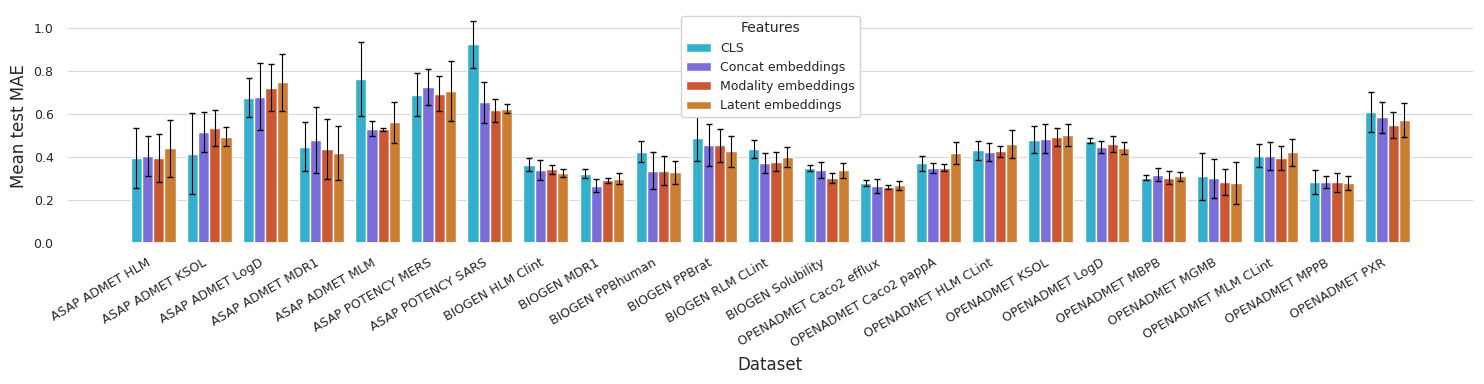

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from colors import DISCRETE_COLORS_BRIGHT

sns.set_theme(style="white")
sns.set(rc={"figure.figsize": (15, 4)})

plot_df = (
    df[df["variant"] == "transformer"]
    .dropna(subset=["mean_test_mae", "std_test_mae"])
    .groupby(["dataset", "features"], as_index=False)
    .agg(
        mean_test_mae=("mean_test_mae", "first"),
        std_test_mae=("std_test_mae", "first"),
    )
)

# Map feature names
feature_mapping = {
    "cls": "CLS",
    "concat": "Concat embeddings",
    "embeddings": "Modality embeddings",
    "latent": "Latent embeddings",
}

plot_df["features"] = plot_df["features"].map(feature_mapping)
n_features = plot_df["features"].nunique()

ax = sns.barplot(
    data=plot_df,
    x="dataset",
    y="mean_test_mae",
    hue="features",
    palette=sns.color_palette(DISCRETE_COLORS_BRIGHT[:n_features]),
    saturation=0.6,
    errorbar=None,
)

# Add std error bars matching each bar's x position
datasets = [t.get_text() for t in ax.get_xticklabels()]
feature_order = [t.get_text() for t in ax.get_legend().get_texts()]
std_lookup = plot_df.set_index(["dataset", "features"])["std_test_mae"].to_dict()

for container, feat in zip(ax.containers, feature_order):
    yerr = [std_lookup.get((ds, feat), 0.0) for ds in datasets]
    xs = [bar.get_x() + bar.get_width() / 2 for bar in container]
    ys = [bar.get_height() for bar in container]
    ax.errorbar(
        xs, ys, yerr=yerr,
        fmt="none", ecolor="black", elinewidth=0.8, capsize=2,
    )

ax.set_ylabel("Mean test MAE")
ax.set_xlabel("Dataset")
ax.set_xticklabels(
    [tick.get_text().replace("_", " ") for tick in ax.get_xticklabels()],
    rotation=30, fontsize=9,
    ha="right",
)
ax.set_yticklabels(
    [tick.get_text().replace("_", " ") for tick in ax.get_yticklabels()], fontsize=9
)
legend = ax.legend(title="Features", loc="upper center", frameon=True, facecolor="white", edgecolor="lightgray", fontsize=9, title_fontsize=10)
legend.get_frame().set_alpha(1.0)

ax.set_facecolor("white")
ax.xaxis.grid(False)
ax.yaxis.grid(True, color="#d9d9d9", linewidth=0.8)

# Save
plt.tight_layout()
plt.savefig("figures/barplot_features.png", dpi=300)


### Performance per probe model across datasets

/tmp/ipykernel_3637275/1420571862.py:25: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  ax = sns.barplot(
/tmp/ipykernel_3637275/1420571862.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_3637275/1420571862.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{tick:.2f}" for tick in ax.get_yticks()], fontsize=8)


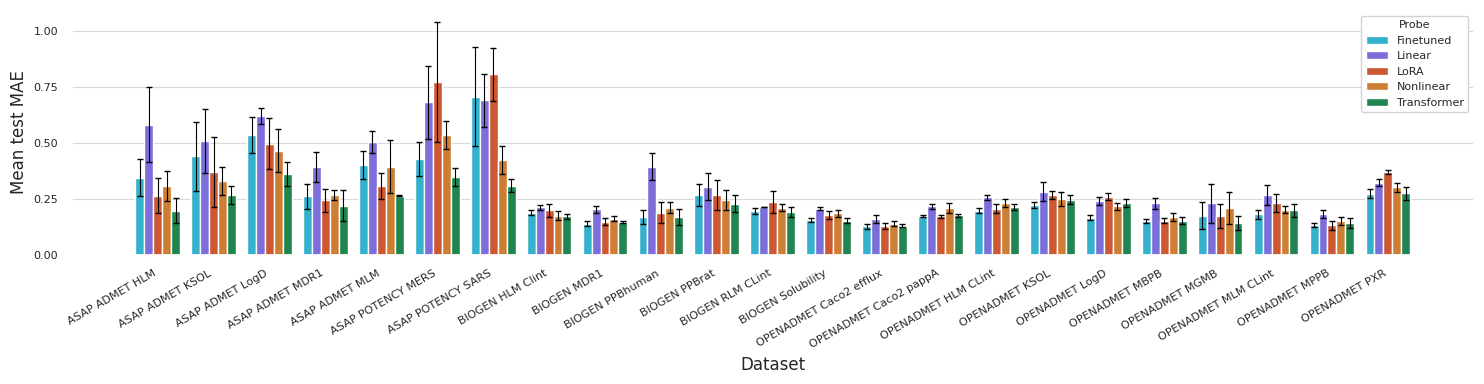

In [8]:
sns.set_theme(style="white")
sns.set(rc={"figure.figsize": (15, 4)})

plot_df = (
    df[df["features"].isin(["embeddings", "tabicl", "lora", "finetuned"])]
    .dropna(subset=["mean_test_mae", "std_test_mae"])
    .groupby(["dataset", "variant"], as_index=False)
    .agg(
        mean_test_mae=("mean_test_mae", "first"),
        std_test_mae=("std_test_mae", "first"),
    )
)

variant_mapping = {
    "lora": "LoRA",
    "linear": "Linear",
    "nonlinear": "Nonlinear",
    "transformer": "Transformer",
    "tabicl": "TabICL",
    "finetuned": "Finetuned",
}

plot_df["variant"] = plot_df["variant"].map(variant_mapping)

ax = sns.barplot(
    data=plot_df,
    x="dataset",
    y="mean_test_mae",
    hue="variant",
    palette=sns.color_palette(DISCRETE_COLORS_BRIGHT[:len(variant_mapping)]),
    saturation=0.6,
    errorbar=None,
)

# Add std error bars matching each bar's x position
datasets = [t.get_text() for t in ax.get_xticklabels()]
variant_order = [t.get_text() for t in ax.get_legend().get_texts()]
std_lookup = plot_df.set_index(["dataset", "variant"])["std_test_mae"].to_dict()

for container, var in zip(ax.containers, variant_order):
    yerr = [std_lookup.get((ds, var), 0.0) for ds in datasets]
    xs = [bar.get_x() + bar.get_width() / 2 for bar in container]
    ys = [bar.get_height() for bar in container]
    try:
        ax.errorbar(
            xs, ys, yerr=yerr,
            fmt="none", ecolor="black", elinewidth=0.8, capsize=2,
        )
    except Exception as e:
        print(f"Error adding error bars for variant '{var}': {e}")

ax.set_facecolor("white")
ax.set_ylabel("Mean test MAE")
ax.set_xlabel("Dataset")
ax.xaxis.grid(False)
ax.yaxis.grid(True, color="#d9d9d9", linewidth=0.8)
ax.set_xticklabels(
    [tick.get_text().replace("_", " ") for tick in ax.get_xticklabels()],
    rotation=30,
    ha="right", fontsize=8
)
ax.set_yticklabels([f"{tick:.2f}" for tick in ax.get_yticks()], fontsize=8)
legend = ax.legend(title="Probe", loc="upper right", fontsize=8, title_fontsize=8,
                   frameon=True, facecolor="white", edgecolor="lightgray")
legend.get_frame().set_alpha(1.0)

# save
plt.tight_layout()
plt.savefig("figures/barplot_variants.png", dpi=300)


### Performance per probe

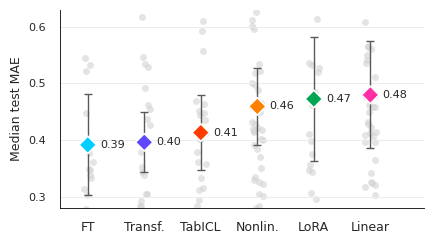

In [9]:
# Lollipop chart with boxenplot distribution behind each probe
sns.set_theme(style="white")

plot_df = df[df["features"].isin(["embeddings", "cls", "lora", "finetuned"])
                & ~((df["variant"] == "transformer") & (df["features"] == "cls"))
].copy()

variant_mapping = {
    "lora": "LoRA",
    "linear": "Linear",
    "nonlinear": "Nonlin.",
    "transformer": "Transf.",
    "tabicl": "TabICL",
    "finetuned": "FT",
}
plot_df["variant"] = plot_df["variant"].map(variant_mapping)

# Order variants by median MAE
variant_order = (
    plot_df.groupby("variant")["mean_test_mae"]
    .median()
    .sort_values()
    .index.tolist()
)

agg = (
    plot_df
    .groupby("variant")
    .agg(median_mae=("mean_test_mae", "median"), mean_cv_std=("std_test_mae", "mean"))
    .reindex(variant_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(4.5, 2.6))

colors = list(DISCRETE_COLORS_BRIGHT)[: len(agg)]
color_map = dict(zip(agg["variant"], colors))
x = np.arange(len(agg))
medians = agg["median_mae"].values
stds = agg["mean_cv_std"].fillna(0).values

# Trim y-axis
ymin = 0.28
ymax = 0.63

# Boxenplot for distribution (narrow width, behind everything)
sns.stripplot(
    data=plot_df,
    x="variant",
    y="mean_test_mae",
    order=variant_order,
    color="lightgrey",
    size=5, alpha=0.6, jitter=True, ax=ax, zorder=-1
)

# Average CV std whiskers
ax.errorbar(
    x, medians, yerr=stds, 
    fmt="none", ecolor="0.35", elinewidth=1.0, capsize=3, capthick=1.0, zorder=4,
)

# Diamond marker at median
MARKER = "D"
ax.scatter(x, medians, s=80, c=colors, marker=MARKER,
           edgecolor="white", linewidth=1.2, zorder=5)

# Value labels
for xi, m in zip(x, medians):
    ax.text(xi + 0.22, m, f"{m:.2f}",
            ha="left", va="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(agg["variant"], fontsize=9)
ax.set_ylabel("Median test MAE", fontsize=9)
ax.set_xlabel("")
ax.tick_params(axis="y", labelsize=8)
ax.set_xlim(-0.5, len(agg) - 0.5 + 0.45)
ax.set_ylim(ymin, ymax)

# set stepsize for y-axis ticks
yticks = np.arange(ymin + 0.02, ymax, 0.1)
ax.set_yticks(yticks)

ax.yaxis.grid(True, color="#ececec", linewidth=0.7)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(0.6)

plt.tight_layout()
plt.savefig("figures/barplot_variants_mean_mae.png", dpi=300, bbox_inches="tight")

### Summary plot

In [10]:
results  = disp.copy()
for col in results.columns:
    results[col] = pd.to_numeric(results[col].str.split(" ± ").str[0])


Average MAE by benchmark family:
                       ExpansionRx  ASAP / Polaris   PXR  Biogen ADME
Mol-JEPA (best)              0.329           0.521  0.55        0.338
Mol-JEPA (embeddings)        0.361           0.561  0.55        0.350
Chemprop_GNN                 0.349           0.670  0.59        0.403
TabICL_AlvaDesc              0.340           0.566  0.87        0.373
LGBM_AlvaDesc                0.368           0.604  0.87        0.393
Chemeleon                    0.441           0.750  0.66        0.427
RF_ECFP4                     0.467           0.630  0.81        0.573
CLAMP                        0.403           0.903  0.75        0.433


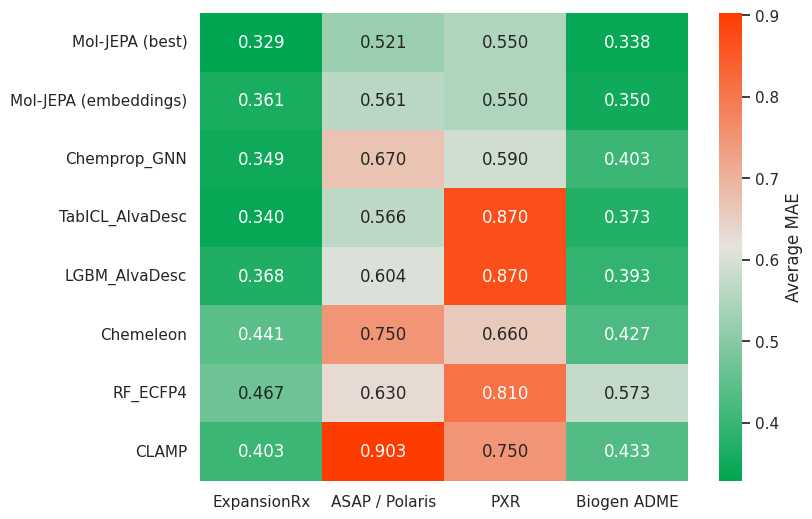

In [11]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from config import BENCHMARK_FAMILIES
from colors import bi_diverging_cmap_red_green

# Average per family
group_mae = pd.DataFrame({
    group: results.loc[datasets].mean()
    for group, datasets in BENCHMARK_FAMILIES.items()
}).T

heatmap_df = group_mae.T.copy()

# Sort models by mean performance across benchmark families
heatmap_df = heatmap_df.loc[heatmap_df.mean(axis=1).sort_values().index]

print("\nAverage MAE by benchmark family:")
print(heatmap_df.round(3))

plt.figure(figsize=(8, 5), facecolor="none")

ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap=bi_diverging_cmap_red_green,
    linewidths=0,
    alpha=1,
    cbar_kws={"label": "Average MAE"},
)

# Remove axes frame
for spine in ax.spines.values():
    spine.set_visible(False)

# Highlight Mol-JEPA row with a border
highlight_model = "Mol-JEPA"
if highlight_model in heatmap_df.index:
    row_idx = heatmap_df.index.get_loc(highlight_model)
    n_cols = heatmap_df.shape[1]
    ax.add_patch(
        Rectangle(
            (0, row_idx),
            n_cols,
            1,
            fill=False,
            edgecolor="black",
            linewidth=2.5,
            clip_on=False,
        )
    )

plt.tight_layout(pad=0)

# Save
plt.savefig("figures/heatmap_benchmark_families.png", dpi=300, bbox_inches="tight")
plt.show()


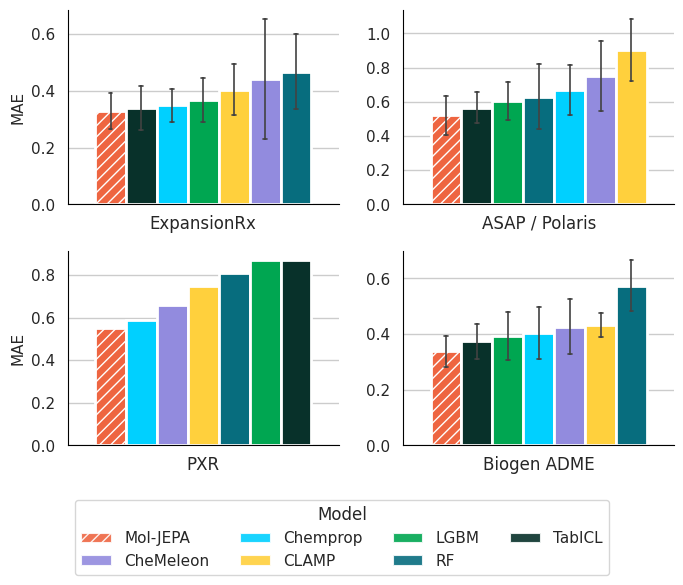

In [12]:
import json
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from config import BENCHMARK_FAMILIES
from colors import DISCRETE_COLORS_ORIG

MOL_JEPA_VARIANT = "best"
models = {
    f"Mol-JEPA ({MOL_JEPA_VARIANT})": "Mol-JEPA",
    "Chemeleon": "CheMeleon",
    "Chemprop_GNN": "Chemprop",
    "CLAMP": "CLAMP",
    "LGBM_AlvaDesc": "LGBM",
    "RF_ECFP4": "RF",
    "TabICL_AlvaDesc": "TabICL",
}

plt_results = results[models.keys()].copy()

palette_map = {
    model: DISCRETE_COLORS_ORIG[i % len(DISCRETE_COLORS_ORIG)]
    for i, model in enumerate(plt_results.columns)
}

records = []
for group_name, datasets in BENCHMARK_FAMILIES.items():
    for dataset in datasets:
        for model_name, mae_val in results.loc[dataset].items():
            if model_name in models:
                records.append({
                    "Benchmark Group": group_name,
                    "Dataset": dataset,
                    "Model": model_name,
                    "MAE": mae_val,
                })

long_df = pd.DataFrame(records)


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(7, 5),
    sharey=False,
    facecolor="white",
)
axes_flat = axes.flatten()

for idx, (ax, group_name) in enumerate(zip(axes_flat, BENCHMARK_FAMILIES.keys())):
    group_df = long_df[long_df["Benchmark Group"] == group_name]

    sorted_models = (
        group_df
        .groupby("Model")["MAE"]
        .mean()
        .sort_values(ascending=True)
        .index.tolist()
    )

    sns.barplot(
        data=group_df,
        x="Benchmark Group",
        y="MAE",
        hue="Model",
        hue_order=sorted_models,
        estimator="mean",
        errorbar="sd",
        capsize=0.1,
        err_kws={"linewidth": 1.2},
        # edgecolor="white",
        linewidth=2,
        palette=palette_map,
        saturation=1,
        alpha=1,
        ax=ax,
    )

    # --- Target Mol-JEPA explicitly by position ---
    mol_jepa_idx = sorted_models.index(f"Mol-JEPA ({MOL_JEPA_VARIANT})")
    patches = ax.patches

    # Seaborn orders patches according to hue_order
    if mol_jepa_idx < len(patches):
        mol_jepa_bar = patches[mol_jepa_idx]
        mol_jepa_bar.set_hatch("///")
        mol_jepa_bar.set_edgecolor("white")
        mol_jepa_bar.set_linewidth(2.0)

    # Axis Formatting
    ax.set_xlabel(group_name, fontsize=12)
    ax.set_xticklabels([])
    ax.tick_params(axis="x", length=0)
    ax.set_ylabel("MAE" if idx % 2 == 0 else "", fontsize=11)
    sns.despine(ax=ax)
    ax.legend().remove()

# --- 4. Unified Legend Setup with Custom Hatch for Mol-JEPA ---
legend_handles = []
for m in models.keys():
    if m == f"Mol-JEPA ({MOL_JEPA_VARIANT})":
        handle = mpatches.Patch(
            facecolor=palette_map[m],
            edgecolor="white",
            hatch="///",
            alpha=0.9,
            linewidth=1.5,
            label=models[m],
        )
    else:
        handle = mpatches.Patch(
            facecolor=palette_map[m],
            edgecolor="white",
            alpha=0.9,
            linewidth=1.5,
            label=models[m],
        )
    legend_handles.append(handle)

fig.legend(
    handles=legend_handles,
    labels=models.values(),
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 0),
    frameon=True,
    ncol=4,
    fontsize=11,
    title_fontsize=12,
)

# Make spines black
for ax in axes_flat:
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig("figures/barplot_benchmark_families_2x2.png", dpi=300, bbox_inches="tight")
plt.show()


### Significance testing

All prediction arrays and y_true have shape (245,).


,model_1,model_2,mae_difference,p_value,p_value_holm,significant
4,Chemprop,LGBM_desc,0.265494,1.386831e-14,2.912345e-13,True
5,Chemprop,RF_ECFP4,0.266886,3.539368e-14,3.716337e-13,True
3,Chemprop,TabICL_desc,0.238583,1.083950e-12,7.587647e-12,True
2,Chemprop,CLAMP,0.234114,1.670100e-09,8.768023e-09,True
14,Chemeleon,RF_ECFP4,0.158650,2.291208e-09,9.623073e-09,True
13,Chemeleon,LGBM_desc,0.157258,6.845361e-09,2.395876e-08,True
9,Mol-JEPA,LGBM_desc,0.219193,3.090811e-08,9.272432e-08,True
12,Chemeleon,TabICL_desc,0.130347,4.098647e-07,1.075895e-06,True
8,Mol-JEPA,TabICL_desc,0.192282,7.527126e-07,1.756329e-06,True
10,Mol-JEPA,RF_ECFP4,0.220584,1.019651e-06,2.141266e-06,True


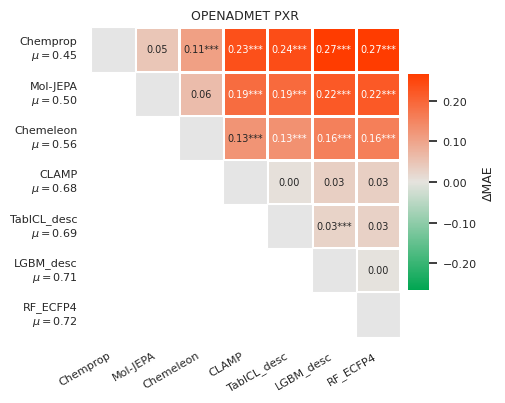

In [13]:
from ast import literal_eval
from itertools import combinations
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
import seaborn as sns
from statsmodels.stats.multitest import multipletests

from colors import bi_diverging_onesided

# Config
DATASET = "OPENADMET_PXR" if "OPENADMET_PXR" in df["dataset"].values else df["dataset"].iloc[0]
COMPARISON_MODELS = [
    "LGBM_desc",
    "RF_ECFP4",
    "Chemprop",
    "TabICL_desc",
    "Chemeleon",
]
ALPHA = 0.05

# Collect predictions and matching ground-truth values.
baseline_subset = baseline_df[baseline_df["dataset"] == DS_MAP[DATASET]]
moljepa_subset = df[(df["dataset"] == DATASET) & (df["variant"] != "clamp")].sort_values(
    by="mean_test_mae", ascending=lower_better
)
clamp_subset = df[(df["dataset"] == DATASET) & (df["variant"] == "clamp")].sort_values(
    "mean_test_mae", ascending=True
)

moljepa_split = literal_eval(moljepa_subset["split1"].iloc[0])
clamp_split = literal_eval(clamp_subset["split1"].iloc[0])

other_preds = {
    model: baseline_subset[baseline_subset["model"] == model]["split1"].iloc[0]["y_pred"]
    for model in COMPARISON_MODELS
}
moljepa_preds = moljepa_split["y_pred_test"]
clamp_preds = clamp_split["y_pred_test"]
y_true = np.asarray(moljepa_split["y_true_test"], dtype=float).ravel()

predictions = {
    "Mol-JEPA": np.asarray(moljepa_preds, dtype=float).ravel(),
    "CLAMP": np.asarray(clamp_preds, dtype=float).ravel(),
    **{
        model: np.asarray(values, dtype=float).ravel()
        for model, values in other_preds.items()
    },
}

# Paired tests require one prediction from every model for each sample.
shapes = {"y_true": y_true.shape} | {
    model: values.shape for model, values in predictions.items()
}
if len(set(shapes.values())) != 1:
    raise ValueError(f"Prediction shapes do not match: {shapes}")
print(f"All prediction arrays and y_true have shape {y_true.shape}.")

# Compare paired absolute errors and order models by MAE (strongest first).
absolute_errors = {
    model: np.abs(y_true - values) for model, values in predictions.items()
}
mean_maes = pd.Series({model: errors.mean() for model, errors in absolute_errors.items()})
model_order = mean_maes.sort_values().index.tolist()
pairs = list(combinations(model_order, 2))

raw_p_values = []
mean_differences = []
for model_1, model_2 in pairs:
    errors_1, errors_2 = absolute_errors[model_1], absolute_errors[model_2]
    difference = errors_2 - errors_1
    mean_differences.append(difference.mean())
    raw_p_values.append(
        1.0 if np.allclose(difference, 0) else wilcoxon(errors_1, errors_2).pvalue
    )

_, adjusted_p_values, _, _ = multipletests(
    raw_p_values,
    alpha=ALPHA,
    method="fdr_bh",
)

pairwise_results = pd.DataFrame(
    {
        "model_1": [pair[0] for pair in pairs],
        "model_2": [pair[1] for pair in pairs],
        "mae_difference": mean_differences,
        "p_value": raw_p_values,
        "p_value_holm": adjusted_p_values,
        "significant": adjusted_p_values <= ALPHA,
    }
).sort_values("p_value_holm")
display(pairwise_results)

# Triangular matrix: positive values mean the row model has lower MAE.
n_models = len(model_order)
diff_mat = pd.DataFrame(np.nan, index=model_order, columns=model_order)
annot_mat = pd.DataFrame("", index=model_order, columns=model_order)

for (model_1, model_2), difference, p_adjusted in zip(
    pairs, mean_differences, adjusted_p_values
):
    diff_mat.loc[model_1, model_2] = abs(difference)
    marker = "***" if p_adjusted <= ALPHA else ""
    annot_mat.loc[model_1, model_2] = f"{difference:.2f}{marker}"

# Plot using the previous triangular heatmap style.
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(5.2, 4.2))
max_abs_difference = max(float(np.nanmax(np.abs(diff_mat.to_numpy()))), 1e-12)

hm = sns.heatmap(
    diff_mat,
    ax=ax,
    mask=np.tril(np.ones((n_models, n_models), dtype=bool), k=-1),
    annot=annot_mat,
    fmt="",
    cmap=bi_diverging_cmap_red_green,
    center=0,
    vmin=-max_abs_difference,
    vmax=max_abs_difference,
    linewidths=0.8,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "ΔMAE",
        "shrink": 0.7,
        "aspect": 10,
        "pad": 0.02,
    },
    # only 2 digits for the annotation text
    annot_kws={"size": 7},
)

cax = hm.collections[0].colorbar.ax
cax.yaxis.label.set_size(9)
cax.tick_params(labelsize=8)
cax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.2f}"))

for i in range(n_models):
    ax.add_patch(
        Rectangle(
            (i, i),
            1,
            1,
            facecolor="#e5e5e5",
            edgecolor="white",
            lw=0.8,
            zorder=3,
        )
    )

ax.set_yticks(np.arange(n_models) + 0.5)
ax.set_yticklabels(
    [f"{model}\n$\\mu={mean_maes[model]:.2f}$" for model in model_order],
    rotation=0,
    fontsize=8,
)
ax.set_xticks(np.arange(n_models) + 0.5)
ax.set_xticklabels(model_order, rotation=30, ha="right", fontsize=8)
ax.set_title(DATASET.replace("_", " "), fontsize=9, pad=6)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(f"figures/pairwise_{DATASET}.png", dpi=300, bbox_inches="tight")
plt.show()

ASAP_ADMET_HLM: Mol-JEPA vs CLAMP => lose
ASAP_ADMET_HLM: Mol-JEPA vs LGBM => lose
ASAP_ADMET_HLM: Mol-JEPA vs RF => lose
ASAP_ADMET_HLM: Mol-JEPA vs Chemprop => lose
ASAP_ADMET_HLM: Mol-JEPA vs TabICL => lose
ASAP_ADMET_HLM: Mol-JEPA vs Chemeleon => lose
ASAP_ADMET_HLM: CLAMP vs Mol-JEPA => lose
ASAP_ADMET_HLM: CLAMP vs LGBM => lose
ASAP_ADMET_HLM: CLAMP vs RF => lose
ASAP_ADMET_HLM: CLAMP vs Chemprop => lose
ASAP_ADMET_HLM: CLAMP vs TabICL => lose
ASAP_ADMET_HLM: CLAMP vs Chemeleon => lose
ASAP_ADMET_HLM: LGBM vs Mol-JEPA => lose
ASAP_ADMET_HLM: LGBM vs CLAMP => lose
ASAP_ADMET_HLM: LGBM vs RF => lose
ASAP_ADMET_HLM: LGBM vs Chemprop => lose
ASAP_ADMET_HLM: LGBM vs TabICL => lose
ASAP_ADMET_HLM: LGBM vs Chemeleon => lose
ASAP_ADMET_HLM: RF vs Mol-JEPA => lose
ASAP_ADMET_HLM: RF vs CLAMP => lose
ASAP_ADMET_HLM: RF vs LGBM => lose
ASAP_ADMET_HLM: RF vs Chemprop => lose
ASAP_ADMET_HLM: RF vs TabICL => lose
ASAP_ADMET_HLM: RF vs Chemeleon => lose
ASAP_ADMET_HLM: Chemprop vs Mol-JEPA => l

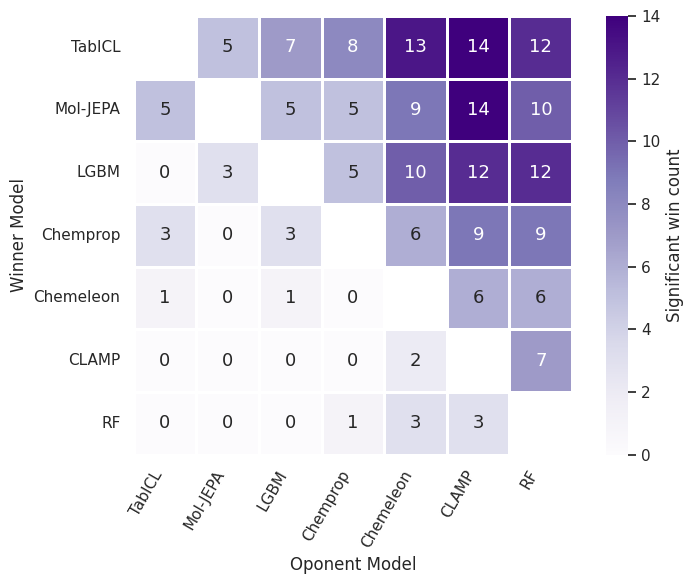

In [14]:
from ast import literal_eval
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import LinearSegmentedColormap

ALPHA = 0.05

COMPARISON_MODELS = [
    "LGBM_desc",
    "RF_ECFP4",
    "Chemprop",
    "TabICL_desc",
    "Chemeleon"
]

MODEL_RENAME = {
    "LGBM_desc": "LGBM",
    "RF_ECFP4": "RF",
    "Chemprop": "Chemprop",
    "TabICL_desc": "TabICL",
    "Chemeleon": "Chemeleon",
    "CLAMP": "CLAMP"
}

all_pairwise_wins = []

for moljepa_ds, benchmark_ds in DS_MAP.items():
    try:
        # ----------------------------------------------------------
        # Load predictions for this dataset
        # ----------------------------------------------------------
        baseline_subset = baseline_df[baseline_df["dataset"] == benchmark_ds]

        moljepa_subset = df[(df["dataset"] == moljepa_ds)].sort_values(
            "mean_test_mae", ascending=True
        )

        clamp_subset = df[(df["dataset"] == moljepa_ds) & (df["variant"] == "clamp")].sort_values(
            "mean_test_mae", ascending=True
        )

        moljepa_split = literal_eval(moljepa_subset["split1"].iloc[0])
        clamp_split = literal_eval(clamp_subset["split1"].iloc[0])

        y_true = np.asarray(
            moljepa_split["y_true_test"],
            dtype=float,
        ).ravel()

        y_true_clamp = np.asarray(
            clamp_split["y_true_test"],
            dtype=float,
        ).ravel()

        predictions = {
            "Mol-JEPA": np.asarray(
                moljepa_split["y_pred_test"],
                dtype=float,
            ).ravel(),
            "CLAMP": np.asarray(
                clamp_split["y_pred_test"],
                dtype=float,
            ).ravel(),
        }

        for model in COMPARISON_MODELS:
            preds = baseline_subset[baseline_subset["model"] == model]["split1"].iloc[
                0
            ]["y_pred"]

            predictions[MODEL_RENAME[model]] = np.asarray(
                preds,
                dtype=float,
            ).ravel()

        # ----------------------------------------------------------
        # Sanity checks
        # ----------------------------------------------------------
        shapes = {model: pred.shape for model, pred in predictions.items()}

        if len(set(shapes.values())) != 1:
            print(f"Skipping {moljepa_ds}: shape mismatch {shapes}")
            continue

        # ----------------------------------------------------------
        # Absolute errors
        # ----------------------------------------------------------
        absolute_errors = {
            model: np.abs(y_true - pred) for model, pred in predictions.items()
        }

        model_names = list(absolute_errors.keys())

        # ----------------------------------------------------------
        # Pairwise Wilcoxon tests
        # ----------------------------------------------------------
        pairs = list(combinations(model_names, 2))

        raw_pvals = []
        mean_diffs = []

        for m1, m2 in pairs:
            err1 = absolute_errors[m1]
            err2 = absolute_errors[m2]

            # negative => m1 better
            mean_diffs.append(err1.mean() - err2.mean())

            raw_pvals.append(
                1.0 if np.allclose(err1, err2) else wilcoxon(err1, err2).pvalue
            )

        _, pvals_adj, _, _ = multipletests(
            raw_pvals,
            alpha=ALPHA,
            method="fdr_bh",
        )

        # ----------------------------------------------------------
        # Significant wins
        # ----------------------------------------------------------
        pairwise_wins = {}

        for (m1, m2), diff, p_adj in zip(
            pairs,
            mean_diffs,
            pvals_adj,
        ):
            if p_adj > ALPHA:
                continue

            winner, loser = (m1, m2) if diff < 0 else (m2, m1)

            pairwise_wins[(winner, loser)] = True

        # ----------------------------------------------------------
        # Record results
        # ----------------------------------------------------------
        for m1 in model_names:
            for m2 in model_names:
                if m1 == m2:
                    continue
                print(f"{moljepa_ds}: {m1} vs {m2} => {'win' if pairwise_wins.get((m1, m2), False) else 'lose'}")
                all_pairwise_wins.append({
                    "Winner": m1,
                    "Loser": m2,
                    "Statistically_Better": int(
                        pairwise_wins.get(
                            (m1, m2),
                            False,
                        )
                    ),
                })

        print(f"Processed {moljepa_ds}")

    except Exception as e:
        print(f"Skipping {moljepa_ds}: {e}")

# ==================================================================
# WIN MATRIX
# ==================================================================

df_pairwise = pd.DataFrame(all_pairwise_wins)

win_matrix = df_pairwise.pivot_table(
    index="Winner",
    columns="Loser",
    values="Statistically_Better",
    aggfunc="sum",
    fill_value=0,
)

net_score = win_matrix.sum(axis=1) - win_matrix.sum(axis=0)

model_order = net_score.sort_values(ascending=False).index

win_matrix = win_matrix.loc[
    model_order,
    model_order,
]

# ==================================================================
# PLOT
# ==================================================================

plt.figure(figsize=(8, 6))


sns.heatmap(
    win_matrix,
    annot=True,
    fmt="d",
    cmap="Purples",
    square=True,
    linewidths=1,
    mask=np.eye(len(win_matrix), dtype=bool),
    cbar_kws={"label": "Significant win count"},
    # Increase annotation font size
    annot_kws={"size": 13},
)

# Rotate x ticks
plt.xticks(rotation=60, ha="right", fontsize=11)

# Set x and y labels
plt.xlabel("Oponent Model", fontsize=12)
plt.ylabel("Winner Model", fontsize=12)

plt.tight_layout()
plt.savefig(
    "figures/model_win_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Winrates

=== MAE win rates ===


,Wilcoxon,MAE
Mol-JEPA,38.1%,82.5%
TabICL,46.8%,73.0%
LGBM,33.3%,55.5%
Chemprop,23.8%,59.1%
CheMeleon,11.1%,35.6%
CLAMP,7.1%,21.9%
RF,5.6%,21.9%


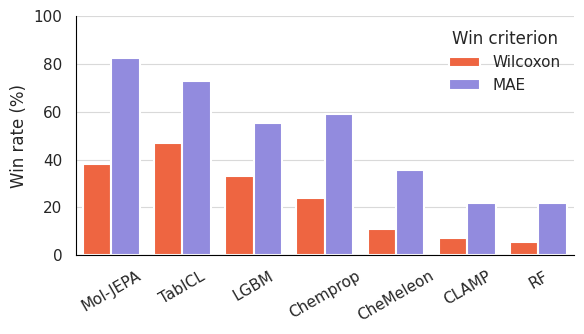


=== R2 win rates ===


,Wilcoxon,R2
TabICL,46.8%,76.6%
Mol-JEPA,38.1%,73.7%
LGBM,33.3%,59.9%
Chemprop,23.8%,59.9%
CheMeleon,11.1%,32.6%
CLAMP,7.1%,25.5%
RF,5.6%,21.2%


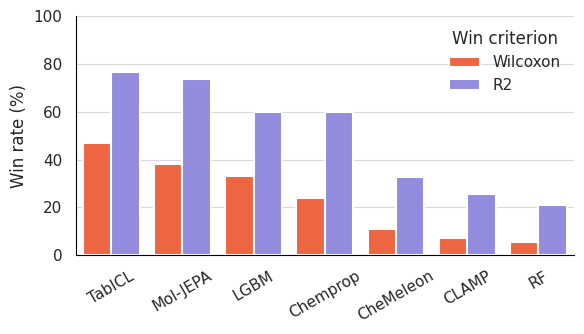

In [15]:
name_map = {
    "Chemprop_GNN": "Chemprop",
    "LGBM_AlvaDesc": "LGBM",
    "RF_ECFP4": "RF",
    "Chemeleon": "Chemeleon",
    "TabICL_AlvaDesc": "TabICL",
    "CLAMP": "CLAMP",
    "Mol-JEPA (embeddings)": "Mol-JEPA",
}


def compute_winrates(metric):
    """Return a DataFrame of win rates (%) for Wilcoxon + the given metric."""
    num = num_mae if metric in ("mae", "mse") else num_r2
    vals = num.drop(index="Average").rename(columns=name_map)[list(name_map.values())]
    lb = metric in ("mae", "mse")

    sig_rate = df_pairwise.groupby("Winner")["Statistically_Better"].mean()

    rate = {}
    for model in vals:
        others = vals.drop(columns=model)
        valid = others.notna() & vals[model].notna().to_numpy()[:, None]
        if lb:
            wins = others.gt(vals[model], axis=0) & valid
        else:
            wins = others.lt(vals[model], axis=0) & valid
        rate[model] = wins.sum().sum() / valid.sum().sum()

    crit = ["Wilcoxon", metric.upper()]
    winrates = (
        pd.concat(
            [sig_rate.rename("Wilcoxon"), pd.Series(rate, name=metric.upper())],
            axis=1,
        )
        .dropna()
        .mul(100)
        .rename(index={"Chemeleon": "CheMeleon"})
    )
    return winrates[crit]


def plot_winrates(winrates, metric, save_path=None):
    """Plot Wilcoxon vs. metric win rates as grouped bars, ordered by overall mean."""
    crit = list(winrates.columns)
    model_order = winrates[crit].mean(axis=1).sort_values(ascending=False).index.tolist()
    winrates = winrates.loc[model_order, crit]
    display(winrates.style.format("{:.1f}%"))

    plot_df = winrates.rename_axis("Model").reset_index().melt(
        "Model", var_name="Criterion", value_name="Win rate (%)"
    )
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(6, 3.5))
    sns.barplot(
        data=plot_df,
        x="Model",
        y="Win rate (%)",
        hue="Criterion",
        order=model_order,
        hue_order=crit,
        palette=DISCRETE_COLORS_ORIG[:2],
        saturation=1,
        alpha=1,
        edgecolor="white",
        linewidth=1.5,
        ax=ax,
    )
    ax.set_ylim(0, 100)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.grid(True, color="#d9d9d9", linewidth=0.8)
    ax.xaxis.grid(False)
    ax.legend(title="Win criterion", frameon=False)
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("black")
        ax.spines[side].set_linewidth(0.8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# Generate both plots on the fly
print("=== MAE win rates ===")
winrates_mae = compute_winrates("mae")
plot_winrates(winrates_mae, "mae", save_path="figures/model_winrates_mae.png")

print("\n=== R2 win rates ===")
winrates_r2 = compute_winrates("r2")
plot_winrates(winrates_r2, "r2", save_path="figures/model_winrates_r2.png")

,Wilcoxon,MAE,R2
TabICL,46.8%,73.0%,76.6%
Mol-JEPA,38.1%,82.5%,73.7%
LGBM,33.3%,55.5%,59.9%
Chemprop,23.8%,59.1%,59.9%
CheMeleon,11.1%,35.6%,32.6%
CLAMP,7.1%,21.9%,25.5%
RF,5.6%,21.9%,21.2%


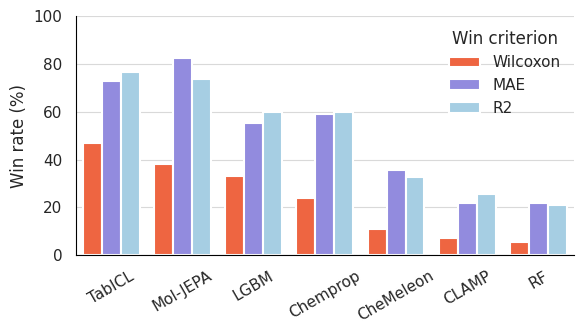

In [16]:
winrates = pd.concat(
    [compute_winrates("mae"), compute_winrates("r2").drop(columns="Wilcoxon")],
    axis=1,
)
criteria = ["Wilcoxon", "MAE", "R2"]
winrates = winrates[criteria]

# Shared order: mean win rate across all three criteria
model_order = winrates[criteria].mean(axis=1).sort_values(ascending=False).index.tolist()
winrates = winrates.loc[model_order, criteria]
display(winrates.style.format("{:.1f}%"))

plot_df = winrates.rename_axis("Model").reset_index().melt(
    "Model", var_name="Criterion", value_name="Win rate (%)"
)
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(
    data=plot_df,
    x="Model",
    y="Win rate (%)",
    hue="Criterion",
    order=model_order,
    hue_order=criteria,
    palette=DISCRETE_COLORS_ORIG[:2] + ["#a6cee3"],
    saturation=1,
    alpha=1,
    edgecolor="white",
    linewidth=1.5,
    ax=ax,
)
ax.set_ylim(0, 100)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.grid(True, color="#d9d9d9", linewidth=0.8)
ax.xaxis.grid(False)
ax.legend(title="Win criterion", frameon=False)
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(0.8)
plt.tight_layout()
plt.savefig("figures/model_winrates_best_public.png", dpi=300, bbox_inches="tight")
plt.show()